In [1]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "oasis_longitudinal.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "jboysen/mri-and-alzheimers",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/Users/ihsanbolum/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/var/folders/ls/vwzpb4gs5p11s0862ytdycch0000gn/T/ipykernel_19881/238782329.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:   Subject ID         MRI ID        Group  Visit  MR Delay M/F Hand  Age  EDUC  \
0  OAS2_0001  OAS2_0001_MR1  Nondemented      1         0   M    R   87    14   
1  OAS2_0001  OAS2_0001_MR2  Nondemented      2       457   M    R   88    14   
2  OAS2_0002  OAS2_0002_MR1     Demented      1         0   M    R   75    12   
3  OAS2_0002  OAS2_0002_MR2     Demented      2       560   M    R   76    12   
4  OAS2_0002  OAS2_0002_MR3     Demented      3      1895   M    R   80    12   

   SES  MMSE  CDR  eTIV   nWBV    ASF  
0  2.0  27.0  0.0  1987  0.696  0.883  
1  2.0  30.0  0.0  2004  0.681  0.876  
2  NaN  23.0  0.5  1678  0.736  1.046  
3  NaN  28.0  0.5  1738  0.713  1.010  
4  NaN  22.0  0.5  1698  0.701  1.034  


In [2]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import StandardScaler

df = df.copy()


df.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


In [3]:
df["Visit"].describe()

count    373.000000
mean       1.882038
std        0.922843
min        1.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        5.000000
Name: Visit, dtype: float64

In [4]:
features_pca = ["MR Delay", "Age", "EDUC", "SES", "MMSE", "eTIV", "nWBV", "ASF"]

df["SES"] = df["SES"].fillna(df["SES"].median())
df["MMSE"] = df["MMSE"].fillna(df["MMSE"].median())

df_visit_1 = df[df["Visit"] == 1].copy()


scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_visit_1[features_pca])

scaled_data.shape

(150, 8)

# PCA - LSTM Trajectory 

In [5]:
df

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,2.0,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,2.0,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,2.0,22.0,0.5,1698,0.701,1.034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,OAS2_0185,OAS2_0185_MR2,Demented,2,842,M,R,82,16,1.0,28.0,0.5,1693,0.694,1.037
369,OAS2_0185,OAS2_0185_MR3,Demented,3,2297,M,R,86,16,1.0,26.0,0.5,1688,0.675,1.040
370,OAS2_0186,OAS2_0186_MR1,Nondemented,1,0,F,R,61,13,2.0,30.0,0.0,1319,0.801,1.331
371,OAS2_0186,OAS2_0186_MR2,Nondemented,2,763,F,R,63,13,2.0,30.0,0.0,1327,0.796,1.323


In [6]:
patience = df.copy() 
len(patience["Visit"] == 1)

373

In [7]:
len(patience[patience["Visit"] == 4])

15

In [8]:
map_dem = {
    "Nondemented": 0,
    "Demented": 1,
    "Converted": 1
}

map_sex = {
    "M": 1,
    "F": 0
}

map_hand = {
    "R": 0,
    "L":1
}

patience["Group"] = patience["Group"].map(map_dem)
patience["Hand"] = patience["Hand"].map(map_hand)
patience["M/F"] = patience["M/F"].map(map_sex)

patience

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,0,1,0,1,0,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,0,2,457,1,0,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,1,1,0,1,0,75,12,2.0,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,1,2,560,1,0,76,12,2.0,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,1,3,1895,1,0,80,12,2.0,22.0,0.5,1698,0.701,1.034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,OAS2_0185,OAS2_0185_MR2,1,2,842,1,0,82,16,1.0,28.0,0.5,1693,0.694,1.037
369,OAS2_0185,OAS2_0185_MR3,1,3,2297,1,0,86,16,1.0,26.0,0.5,1688,0.675,1.040
370,OAS2_0186,OAS2_0186_MR1,0,1,0,0,0,61,13,2.0,30.0,0.0,1319,0.801,1.331
371,OAS2_0186,OAS2_0186_MR2,0,2,763,0,0,63,13,2.0,30.0,0.0,1327,0.796,1.323


In [9]:

ids_1 = patience[patience["Visit"] == 1]["Subject ID"]
ids_2 = patience[patience["Visit"] == 2]["Subject ID"]



ids_pool_1_2 = set(ids_1).intersection(set(ids_2))


patience_1_2 = patience[patience["Subject ID"].isin(ids_pool_1_2)]

patience_1_2 = patience_1_2[patience_1_2["Visit"].isin([1,2])]


In [10]:
patience_1_2

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,0,1,0,1,0,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,0,2,457,1,0,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,1,1,0,1,0,75,12,2.0,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,1,2,560,1,0,76,12,2.0,28.0,0.5,1738,0.713,1.010
5,OAS2_0004,OAS2_0004_MR1,0,1,0,0,0,88,18,3.0,28.0,0.0,1215,0.710,1.444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366,OAS2_0184,OAS2_0184_MR2,1,2,553,0,0,73,16,3.0,21.0,1.0,1351,0.708,1.299
367,OAS2_0185,OAS2_0185_MR1,1,1,0,1,0,80,16,1.0,28.0,0.5,1704,0.711,1.030
368,OAS2_0185,OAS2_0185_MR2,1,2,842,1,0,82,16,1.0,28.0,0.5,1693,0.694,1.037
370,OAS2_0186,OAS2_0186_MR1,0,1,0,0,0,61,13,2.0,30.0,0.0,1319,0.801,1.331


In [11]:
patience_1_2["Visit"].unique()

array([1, 2])

In [12]:
unique_ids = patience_1_2["Subject ID"].unique()

In [13]:
unique_ids

array(['OAS2_0001', 'OAS2_0002', 'OAS2_0004', 'OAS2_0005', 'OAS2_0008',
       'OAS2_0009', 'OAS2_0010', 'OAS2_0012', 'OAS2_0013', 'OAS2_0014',
       'OAS2_0016', 'OAS2_0020', 'OAS2_0021', 'OAS2_0022', 'OAS2_0023',
       'OAS2_0026', 'OAS2_0027', 'OAS2_0028', 'OAS2_0029', 'OAS2_0030',
       'OAS2_0031', 'OAS2_0032', 'OAS2_0034', 'OAS2_0035', 'OAS2_0037',
       'OAS2_0039', 'OAS2_0040', 'OAS2_0041', 'OAS2_0042', 'OAS2_0043',
       'OAS2_0044', 'OAS2_0045', 'OAS2_0046', 'OAS2_0047', 'OAS2_0048',
       'OAS2_0049', 'OAS2_0050', 'OAS2_0051', 'OAS2_0052', 'OAS2_0053',
       'OAS2_0054', 'OAS2_0055', 'OAS2_0056', 'OAS2_0057', 'OAS2_0058',
       'OAS2_0060', 'OAS2_0061', 'OAS2_0062', 'OAS2_0063', 'OAS2_0064',
       'OAS2_0066', 'OAS2_0067', 'OAS2_0068', 'OAS2_0069', 'OAS2_0070',
       'OAS2_0071', 'OAS2_0073', 'OAS2_0075', 'OAS2_0076', 'OAS2_0077',
       'OAS2_0078', 'OAS2_0079', 'OAS2_0080', 'OAS2_0081', 'OAS2_0085',
       'OAS2_0086', 'OAS2_0087', 'OAS2_0088', 'OAS2_0090', 'OAS2

In [14]:
from sklearn.model_selection import train_test_split
df_train_id, df_test_id = train_test_split(unique_ids, test_size=0.2, random_state=42)

df_train = patience_1_2[patience_1_2["Subject ID"].isin(df_train_id)]
df_test = patience_1_2[patience_1_2["Subject ID"].isin(df_test_id)]

In [15]:
df_train.head()


,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,0,1,0,1,0,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,0,2,457,1,0,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,1,1,0,1,0,75,12,2.0,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,1,2,560,1,0,76,12,2.0,28.0,0.5,1738,0.713,1.010
5,OAS2_0004,OAS2_0004_MR1,0,1,0,0,0,88,18,3.0,28.0,0.0,1215,0.710,1.444


In [16]:
df_test.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
13,OAS2_0008,OAS2_0008_MR1,0,1,0,0,0,93,14,2.0,30.0,0.0,1272,0.698,1.380
14,OAS2_0008,OAS2_0008_MR2,0,2,742,0,0,95,14,2.0,29.0,0.0,1257,0.703,1.396
25,OAS2_0014,OAS2_0014_MR1,1,1,0,1,0,76,16,3.0,21.0,0.5,1602,0.697,1.096
26,OAS2_0014,OAS2_0014_MR2,1,2,504,1,0,77,16,3.0,16.0,1.0,1590,0.696,1.104
36,OAS2_0020,OAS2_0020_MR1,1,1,0,1,0,80,20,1.0,29.0,0.0,1587,0.693,1.106


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
scale = StandardScaler()
pca = PCA(n_components=2)
def scale_data_PCA(df, n):

    pca_featres = ["MR Delay"	,"M/F"	,"Hand"	,"Age"	,"EDUC"	,"SES"	,"MMSE"	,"eTIV"	,"nWBV","ASF"]

    if n == 1: #train
        

        pca_scale = scale.fit_transform(df[pca_featres])
        pca_res = pca.fit_transform(pca_scale)

        pca_res = pd.DataFrame(data=pca_res, columns=["PC1", "PC2"], index=df.index)
        df = pd.concat([df, pca_res], axis=1)
        return df

    if n == 2 : #test

        pca_scale = scale.transform(df[pca_featres])
        pca_res = pca.transform(pca_scale)

        pca_res = pd.DataFrame(data=pca_res, columns=["PC1", "PC2"], index=df.index)



        df = pd.concat([df, pca_res], axis=1)
        return df
    return

In [18]:
df_train = scale_data_PCA(df_train,1)
df_test = scale_data_PCA(df_test,2)

In [19]:
features_lstm = ["MR Delay",	"Age"	,"EDUC"	,"SES"	,"MMSE"	,"eTIV"	,"nWBV"	,"ASF"]
import joblib
df_train[features_lstm] = scaler.fit_transform(df_train[features_lstm])
df_test[features_lstm] = scaler.transform(df_test[features_lstm])
joblib.dump(scaler, "alz_scaler.save")

df_test.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,PC1,PC2
13,OAS2_0008,OAS2_0008_MR1,0,1,-0.894294,0,0,2.250713,-0.214579,-0.392626,0.821900,0.0,-1.186405,-0.829575,1.270275,-1.447290,-0.050004
14,OAS2_0008,OAS2_0008_MR2,0,2,1.008322,0,0,2.522953,-0.214579,-0.392626,0.537634,0.0,-1.270977,-0.693385,1.383533,-1.466141,-0.352286
25,OAS2_0014,OAS2_0014_MR1,1,1,-0.894294,1,0,-0.063325,0.490465,0.548040,-1.736494,0.5,0.674171,-0.856813,-0.740055,1.315268,-1.508672
26,OAS2_0014,OAS2_0014_MR2,1,2,0.398049,1,0,0.072795,0.490465,0.548040,-3.157824,1.0,0.606514,-0.884051,-0.683426,1.297885,-2.349589
36,OAS2_0020,OAS2_0020_MR1,1,1,-0.894294,1,0,0.481154,1.900553,-1.333292,0.537634,0.0,0.589599,-0.965765,-0.669269,2.287169,0.906552


In [20]:
def reshape_dim(df, features, n_visit):
    n_id = df["Subject ID"].nunique()
    n_features = len(features)
    print(n_id)

    df = df.sort_values(by=["Subject ID", "Visit"] )

    df_3d = df[features].values.reshape(n_id, n_visit, n_features)

    

    return df_3d

In [21]:
df_test.shape

(58, 17)

In [22]:
df_train.shape

(230, 17)

In [23]:
df_test_3d = reshape_dim(df_test, features_lstm, 2)
df_train_3d = reshape_dim(df_train, features_lstm, 2)

print(df_test_3d.shape, df_train_3d.shape)

29
115
(29, 2, 8) (115, 2, 8)


In [24]:
X_train_2v = df_train_3d[:, :2, :]
X_test_2v = df_test_3d[:, :2, :]


X_train_2v = np.asarray(X_train_2v).astype('float32')
X_test_2v = np.asarray(X_test_2v).astype('float32')

In [82]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout


inputs = Input(shape=(2, 8), name='input_layer')
lstm_out= LSTM(units=8, activation="tanh")(inputs)

dropout_ra = Dropout(0.3)(lstm_out)

pca_output = Dense(units=2, activation="linear", name="pca_prediction")(dropout_ra)
group_output = Dense(units=1, activation="sigmoid", name="group_prediction")(dropout_ra)

model = Model(inputs=inputs, outputs=[pca_output, group_output])

model.compile(
    optimizer="adam",
    loss={
        "pca_prediction": "mse",
        "group_prediction": "binary_crossentropy"
    },
    metrics={
        'pca_prediction': 'mae',                 
        'group_prediction': 'accuracy'
    },
    loss_weights={
       'pca_prediction': 0.01, 
        'group_prediction': 2.0# 8 -> 7 -> 6 
    }
)




Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - group_prediction_accuracy: 0.4731 - group_prediction_loss: 0.7036 - loss: 1.4363 - pca_prediction_loss: 2.9912 - pca_prediction_mae: 1.3648 - val_group_prediction_accuracy: 0.4828 - val_group_prediction_loss: 0.7070 - val_loss: 1.4297 - val_pca_prediction_loss: 2.4405 - val_pca_prediction_mae: 1.2760
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - group_prediction_accuracy: 0.5744 - group_prediction_loss: 0.6749 - loss: 1.3759 - pca_prediction_loss: 2.7034 - pca_prediction_mae: 1.3374 - val_group_prediction_accuracy: 0.5172 - val_group_prediction_loss: 0.7035 - val_loss: 1.4235 - val_pca_prediction_loss: 2.4174 - val_pca_prediction_mae: 1.2715
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - group_prediction_accuracy: 0.6802 - group_prediction_loss: 0.6520 - loss: 1.3322 - pca_prediction_loss: 2.7808 - pca_prediction_mae: 1.3499 - val_group_prediction_accuracy: 0.5172 - val_group_prediction_loss: 0.7003 - val_loss: 1.4177 -

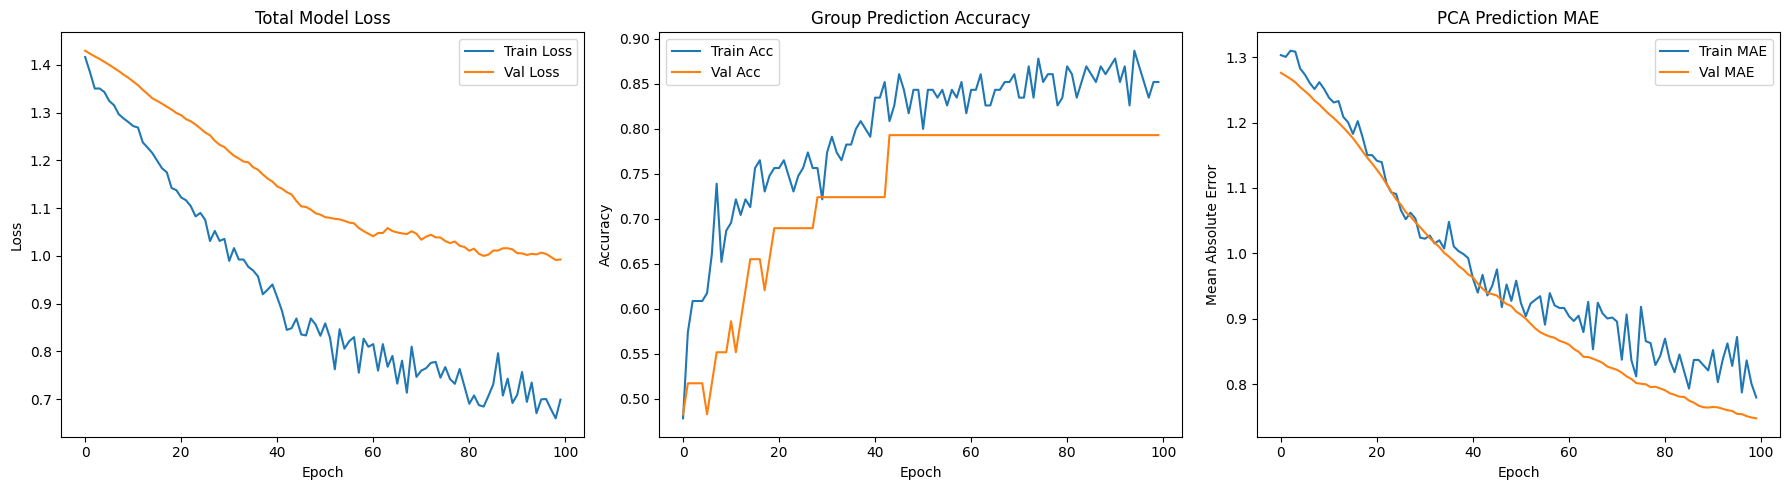

In [83]:

y_train_pca = df_train.groupby("Subject ID")[["PC1", "PC2"]].last()
y_train_group = df_train.groupby("Subject ID")["Group"].first()

y_test_pca = df_test.groupby("Subject ID")[["PC1", "PC2"]].last()
y_test_group = df_test.groupby("Subject ID")["Group"].first()

y_train_dict = {
    'pca_prediction': y_train_pca,
    'group_prediction': y_train_group
}

y_test_dict = {
    'pca_prediction': y_test_pca,
    'group_prediction': y_test_group
}


y_train_dict['pca_prediction'] = np.asarray(y_train_dict['pca_prediction']).astype('float32')
y_train_dict['group_prediction'] = np.asarray(y_train_dict['group_prediction']).astype('float32')

y_test_dict['pca_prediction'] = np.asarray(y_test_dict['pca_prediction']).astype('float32')
y_test_dict['group_prediction'] = np.asarray(y_test_dict['group_prediction']).astype('float32')
history = model.fit(
    X_train_2v,           
    y_train_dict,         
    epochs=100,
    batch_size=8,
    validation_data=(X_test_2v, y_test_dict),
    verbose=1,

)
import matplotlib.pyplot as plt

def plot_history(history):

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))


    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Total Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(history.history['group_prediction_accuracy'], label='Train Acc')
    ax2.plot(history.history['val_group_prediction_accuracy'], label='Val Acc')
    ax2.set_title('Group Prediction Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()


    ax3.plot(history.history['pca_prediction_mae'], label='Train MAE')
    ax3.plot(history.history['val_pca_prediction_mae'], label='Val MAE')
    ax3.set_title('PCA Prediction MAE')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Mean Absolute Error')
    ax3.legend()

    plt.tight_layout()
    plt.show()


plot_history(history)

In [84]:
model.save('pca_trajectory_model.keras')

# Visit 4 Prediction

In [85]:
df["Visit"].unique()

array([1, 2, 3, 4, 5])

In [86]:
df_v4 = df[df["Visit"] == 4]["Subject ID"]
df_v3 = df[df["Visit"] ==3]["Subject ID"]

ids_v_3_4 = set(df_v3).intersection(set(df_v4))

df_visit3_4 = df[df["Subject ID"].isin(ids_v_3_4)].copy()
df_visit3_4 = df_visit3_4[df_visit3_4["Visit"].isin([3,4])]

In [87]:
def pca_results_plot(df, visit):
    scaler = StandardScaler()
    pca = PCA(n_components=2)
    df = df.copy()
    
    map_dem = {"Nondemented": 0, "Demented": 1, "Converted": 1}
    map_sex = {"M": 1, "F": 0}
    map_hand = {"R": 0, "L":1}

    df["Group"] = df["Group"].map(map_dem)
    df["Hand"] = df["Hand"].map(map_hand)
    df["M/F"] = df["M/F"].map(map_sex)
    
    pca_featres = ["MR Delay", "M/F", "Hand", "Age", "EDUC", "SES", "MMSE", "eTIV", "nWBV", "ASF"]
    
    # Filtern nach Visit
    df = df[df["Visit"] == visit].copy()
    


    scale_data = scaler.fit_transform(df[pca_featres])
    pca_res = pca.fit_transform(scale_data)

    # Wir erstellen den DataFrame, aber brauchen den Index nicht mehr zwingend für die Schleife
    pca_df = pd.DataFrame(data=pca_res, columns=["PC1", "PC2"])

    plt.figure(figsize=(10, 7))

    # Wir iterieren über die Länge des DataFrames
    for i in range(len(pca_df)):
        # 1. Koordinaten holen
        x = pca_df["PC1"].iloc[i]
        y = pca_df["PC2"].iloc[i]
        
        # 2. Gruppe über die Position holen (iloc)
        group_val = df["Group"].iloc[i]
        point_color = 'red' if group_val == 1 else 'green'
        
        # 3. Subject ID über die Position holen und kürzen
        full_id = df["Subject ID"].iloc[i]
        try:
            # Macht aus 'OAS2_0007' -> '7'
            short_id = str(int(str(full_id).split('_')[1]))
        except:
            short_id = str(full_id)
        
        # 4. Plotten und Beschriften
        plt.scatter(x, y, color=point_color, alpha=0.7, s=50)
        plt.annotate(short_id, (x, y), xytext=(5, 2), textcoords='offset points', fontsize=9)
        
    plt.xlabel('Principal Component 1 (PC1)')
    plt.ylabel('Principal Component 2 (PC2)')
    plt.title(f'PCA - Wahre Daten für Visit {visit}')
    plt.grid(True, alpha=0.3)
    plt.show()

In [88]:
model_alzeh = tf.keras.models.load_model("pca_trajectory_model.keras")

In [89]:
def prep_data_predict(df):
    scaler = joblib.load("alz_scaler.save")
    df = df.copy()
    df["Group"] = df["Group"].map(map_dem)

    df["Hand"] = df["Hand"].map(map_hand)

    df["M/F"] = df["M/F"].map(map_sex)

    features_lstm = ["MR Delay",	"Age"	,"EDUC"	,"SES"	,"MMSE"		,"eTIV"	,"nWBV"	,"ASF"]
    df[features_lstm] = scaler.transform(df[features_lstm])
    print(df[features_lstm].shape)
#    model = tf.keras.models.load_model("pca_trajectory_model.keras")
 #   #input_data = df[features_lstm].reshape((1,9,None))
  #  predictions = model.predict(df[features_lstm])
    return df[features_lstm]#predictions


In [90]:
#df_visit3_4_reshaped = df_visit3_4.values.reshape(-1,2,9) 
df_visit3_4_clean = prep_data_predict(df_visit3_4)

df_visit3_4_reshaped = df_visit3_4_clean.values.reshape(-1,2,8)


(30, 8)


In [91]:
model = tf.keras.models.load_model("pca_trajectory_model.keras")
predictions = model.predict(df_visit3_4_reshaped)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


In [92]:
predictions[1]

array([[0.7315443 ],
       [0.3690934 ],
       [0.66923225],
       [0.43884018],
       [0.5666515 ],
       [0.33581427],
       [0.7845356 ],
       [0.98966795],
       [0.66576093],
       [0.6896852 ],
       [0.60106593],
       [0.41854706],
       [0.6644479 ],
       [0.5237205 ],
       [0.5414202 ]], dtype=float32)

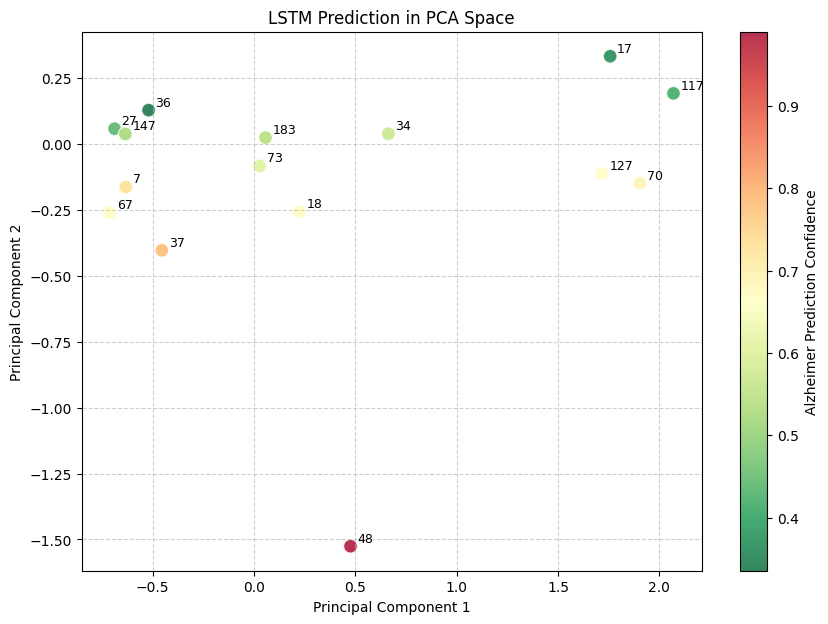

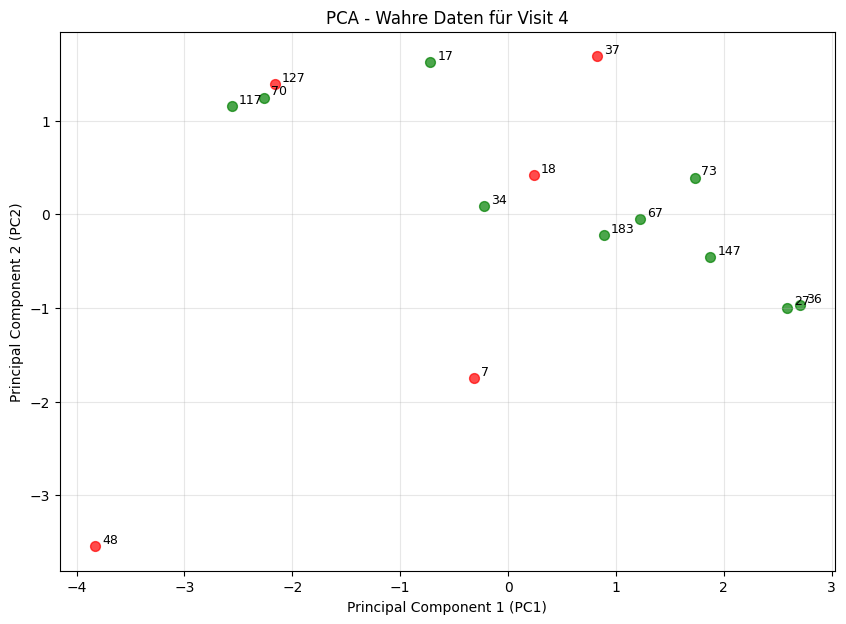

In [93]:
import matplotlib.pyplot as plt
import numpy as np

pca_coords = predictions[0]
confidence = predictions[1]

# Get unique Subject IDs in the same order used for reshaping
subject_ids = df_visit3_4.sort_values(by=["Subject ID", "Visit"])["Subject ID"].unique()

plt.figure(figsize=(10, 7))

scatter = plt.scatter(pca_coords[:, 0], pca_coords[:, 1], 
                      c=confidence.flatten(), 
                      cmap='RdYlGn_r', 
                      s=100,           
                      edgecolors='w',
                      alpha=0.8) 

cbar = plt.colorbar(scatter)
cbar.set_label('Alzheimer Prediction Confidence')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('LSTM Prediction in PCA Space')
plt.grid(True, linestyle='--', alpha=0.6)

for i in range(len(pca_coords)):
    x = pca_coords[i, 0]
    y = pca_coords[i, 1]
    sid = subject_ids[i]
    try:
        short_id = str(int(str(sid).split('_')[1]))
    except:
        short_id = str(sid)
    plt.annotate(short_id, (x, y), xytext=(5, 3), textcoords='offset points', fontsize=9)

plt.show()

pca_results_plot(df_visit3_4,4)


# UMAP - LSTM Trajectory

In [37]:
df_umap = df.copy()

len(df_umap)

373

In [38]:
df_umap_v_1 = df_umap[df_umap["Visit"] == 1]["Subject ID"]
df_umap_v_2 = df_umap[df_umap["Visit"] == 2]["Subject ID"]

df_umap_v_1_2 = set(df_umap_v_1).intersection(set(df_umap_v_2))

df_umap_v_1_2 = df_umap[df_umap["Subject ID"].isin(df_umap_v_1_2) & df_umap["Visit"].isin([1, 2])]
df_umap_v_1_2["Visit"].unique()
df_umap_v_1_2

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,2.0,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,2.0,28.0,0.5,1738,0.713,1.010
5,OAS2_0004,OAS2_0004_MR1,Nondemented,1,0,F,R,88,18,3.0,28.0,0.0,1215,0.710,1.444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366,OAS2_0184,OAS2_0184_MR2,Demented,2,553,F,R,73,16,3.0,21.0,1.0,1351,0.708,1.299
367,OAS2_0185,OAS2_0185_MR1,Demented,1,0,M,R,80,16,1.0,28.0,0.5,1704,0.711,1.030
368,OAS2_0185,OAS2_0185_MR2,Demented,2,842,M,R,82,16,1.0,28.0,0.5,1693,0.694,1.037
370,OAS2_0186,OAS2_0186_MR1,Nondemented,1,0,F,R,61,13,2.0,30.0,0.0,1319,0.801,1.331


In [39]:
map_dem = {
    "Nondemented": 0,
    "Demented": 1,
    "Converted": 1
}

map_sex = {
    "M": 1,
    "F": 0
}

map_hand = {
    "R": 0,
    "L":1
}

df_umap_v_1_2["Group"] = df_umap_v_1_2["Group"].map(map_dem)
df_umap_v_1_2["Hand"] = df_umap_v_1_2["Hand"].map(map_hand)
df_umap_v_1_2["M/F"] = df_umap_v_1_2["M/F"].map(map_sex)

df_umap_v_1_2.head()

/var/folders/ls/vwzpb4gs5p11s0862ytdycch0000gn/T/ipykernel_19881/1721452940.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_umap_v_1_2["Group"] = df_umap_v_1_2["Group"].map(map_dem)
/var/folders/ls/vwzpb4gs5p11s0862ytdycch0000gn/T/ipykernel_19881/1721452940.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_umap_v_1_2["Hand"] = df_umap_v_1_2["Hand"].map(map_hand)
/var/folders/ls/vwzpb4gs5p11s0862ytdycch0000gn/T/ipykernel_19881/1721452940.py:19: SettingWithCopyWarning: 
A value is trying to be s

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,0,1,0,1,0,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,0,2,457,1,0,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,1,1,0,1,0,75,12,2.0,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,1,2,560,1,0,76,12,2.0,28.0,0.5,1738,0.713,1.010
5,OAS2_0004,OAS2_0004_MR1,0,1,0,0,0,88,18,3.0,28.0,0.0,1215,0.710,1.444


In [40]:
from sklearn.model_selection import train_test_split
df_umap_v_1_2_uniqueID = df_umap_v_1_2["Subject ID"].unique()
df_train_umap, df_test_umap = train_test_split(df_umap_v_1_2_uniqueID, test_size=0.2, random_state=42)

df_train_umap = df_umap_v_1_2[df_umap_v_1_2["Subject ID"].isin(df_train_umap)]
df_test_umap = df_umap_v_1_2[df_umap_v_1_2["Subject ID"].isin(df_test_umap)]


In [41]:
df_train_umap.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,0,1,0,1,0,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,0,2,457,1,0,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,1,1,0,1,0,75,12,2.0,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,1,2,560,1,0,76,12,2.0,28.0,0.5,1738,0.713,1.010
5,OAS2_0004,OAS2_0004_MR1,0,1,0,0,0,88,18,3.0,28.0,0.0,1215,0.710,1.444


In [42]:
df_test_umap.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
13,OAS2_0008,OAS2_0008_MR1,0,1,0,0,0,93,14,2.0,30.0,0.0,1272,0.698,1.380
14,OAS2_0008,OAS2_0008_MR2,0,2,742,0,0,95,14,2.0,29.0,0.0,1257,0.703,1.396
25,OAS2_0014,OAS2_0014_MR1,1,1,0,1,0,76,16,3.0,21.0,0.5,1602,0.697,1.096
26,OAS2_0014,OAS2_0014_MR2,1,2,504,1,0,77,16,3.0,16.0,1.0,1590,0.696,1.104
36,OAS2_0020,OAS2_0020_MR1,1,1,0,1,0,80,20,1.0,29.0,0.0,1587,0.693,1.106


In [43]:
def umap_cal(df_train, df_test,n_neighbors, min_dist, n_components, metric):
    features = [ "Visit", "MR Delay",	"M/F",	"Hand",	"Age",	"EDUC",	"SES",	"MMSE",	"eTIV",	"nWBV",	"ASF"]

    data_umap_train = df_train[features]
    data_umap_test = df_test[features]



    import umap 

    reducer = umap.UMAP(n_neighbors=n_neighbors, 
                        min_dist=min_dist, 
                        n_components=n_components, 
                        metric=f'{metric}')

    embedding_train = reducer.fit_transform(data_umap_train)
    embedding_test = reducer.transform(data_umap_test)


    return embedding_train,embedding_test

In [44]:
train_umap_cor, test_umap_cor =umap_cal(df_train_umap,df_test_umap, 5, 1, 2, "euclidean")
train_umap_cor = pd.DataFrame(data=train_umap_cor, columns=["UMAP1", "UMAP2"], index=df_train_umap)

test_umap_cor = pd.DataFrame(data=test_umap_cor, columns=["UMAP1", "UMAP2"], index=df_test_umap)



In [45]:
df_train_umap[features_lstm] = scaler.fit_transform(df_train_umap[features_lstm])
df_test_umap[features_lstm] = scaler.transform(df_test_umap[features_lstm])

joblib.dump(scaler, "alz_scaler_umap.save")



/var/folders/ls/vwzpb4gs5p11s0862ytdycch0000gn/T/ipykernel_19881/1772528806.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_umap[features_lstm] = scaler.fit_transform(df_train_umap[features_lstm])
/var/folders/ls/vwzpb4gs5p11s0862ytdycch0000gn/T/ipykernel_19881/1772528806.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_umap[features_lstm] = scaler.transform(df_test_umap[features_lstm])


['alz_scaler_umap.save']

In [46]:
#df_train_umap = pd.concat([df_train_umap.reset_index(drop=True),train_umap_cor.reset_index(drop=True)], axis=1)
#df_test_umap = pd.concat([df_train_umap.reset_index(drop=True),test_umap_cor.reset_index(drop=True)], axis=1)
df_train_umap = pd.concat(                                                                                                                                                          
    [df_train_umap.reset_index(drop=True), train_umap_cor.reset_index(drop=True)],                                                                                                  
    axis=1,                                                                                                                                                                         
)                                                                                                                                                                                   
df_test_umap = pd.concat(                                                                                                                                                           
    [df_test_umap.reset_index(drop=True),  test_umap_cor.reset_index(drop=True)],
    axis=1,                                                                                                                                                                         
)
df_train_umap = df_train_umap.drop(columns=["CDR", "MRI ID"	])
df_train_umap


,Subject ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,eTIV,nWBV,ASF,UMAP1,UMAP2
0,OAS2_0001,0,1,-0.894294,1,0,1.433994,-0.214579,-0.392626,-0.030898,2.844843,-0.884051,-2.247802,10.476352,16.317003
1,OAS2_0001,0,2,0.277533,1,0,1.570114,-0.214579,-0.392626,0.821900,2.940691,-1.292621,-2.297352,10.309221,5.897851
2,OAS2_0002,1,1,-0.894294,1,0,-0.199445,-0.919623,-0.392626,-1.167962,1.102667,0.205469,-1.093986,5.320234,16.124784
3,OAS2_0002,1,2,0.541643,1,0,-0.063325,-0.919623,-0.392626,0.253368,1.440954,-0.421005,-1.348817,11.013754,5.704039
4,OAS2_0004,0,1,-0.894294,0,0,1.570114,1.195509,0.548040,0.253368,-1.507778,-0.502719,1.723307,-2.485117,-4.525013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,OAS2_0184,1,2,0.523693,0,0,-0.471685,0.490465,0.548040,-1.736494,-0.740995,-0.557195,0.696906,20.355289,2.092590
226,OAS2_0185,1,1,-0.894294,1,0,0.481154,0.490465,-1.333292,0.253368,1.249258,-0.475481,-1.207244,6.441936,14.641016
227,OAS2_0185,1,2,1.264739,1,0,0.753394,0.490465,-1.333292,0.253368,1.187239,-0.938527,-1.157694,12.714470,0.694650
228,OAS2_0186,0,1,-0.894294,0,0,-2.105124,-0.567101,-0.392626,0.821900,-0.921414,1.975940,0.923422,-0.718413,1.697987


In [47]:
df_train_umap_3d = reshape_dim(df_train_umap, features_lstm,2)
df_test_umap_3d = reshape_dim(df_test_umap, features_lstm,2)


115
29


Epoch 1/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - group_prediction_accuracy: 0.3633 - group_prediction_loss: 0.7344 - loss: 2.8303 - umap_prediction_loss: 139.7442 - umap_prediction_mae: 9.8526 - val_group_prediction_accuracy: 0.4828 - val_group_prediction_loss: 0.7011 - val_loss: 2.5737 - val_umap_prediction_loss: 124.4059 - val_umap_prediction_mae: 9.1892
Epoch 2/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - group_prediction_accuracy: 0.3059 - group_prediction_loss: 0.7374 - loss: 2.7106 - umap_prediction_loss: 131.3898 - umap_prediction_mae: 9.6112 - val_group_prediction_accuracy: 0.4483 - val_group_prediction_loss: 0.6942 - val_loss: 2.5594 - val_umap_prediction_loss: 123.8640 - val_umap_prediction_mae: 9.1703
Epoch 3/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - group_prediction_accuracy: 0.3257 - group_prediction_loss: 0.7248 - loss: 2.6045 - umap_prediction_loss: 125.5080 - umap_prediction_mae: 9.4701 - val_group_prediction_accuracy: 0.4828 - val_group_prediction_loss: 0.6881 

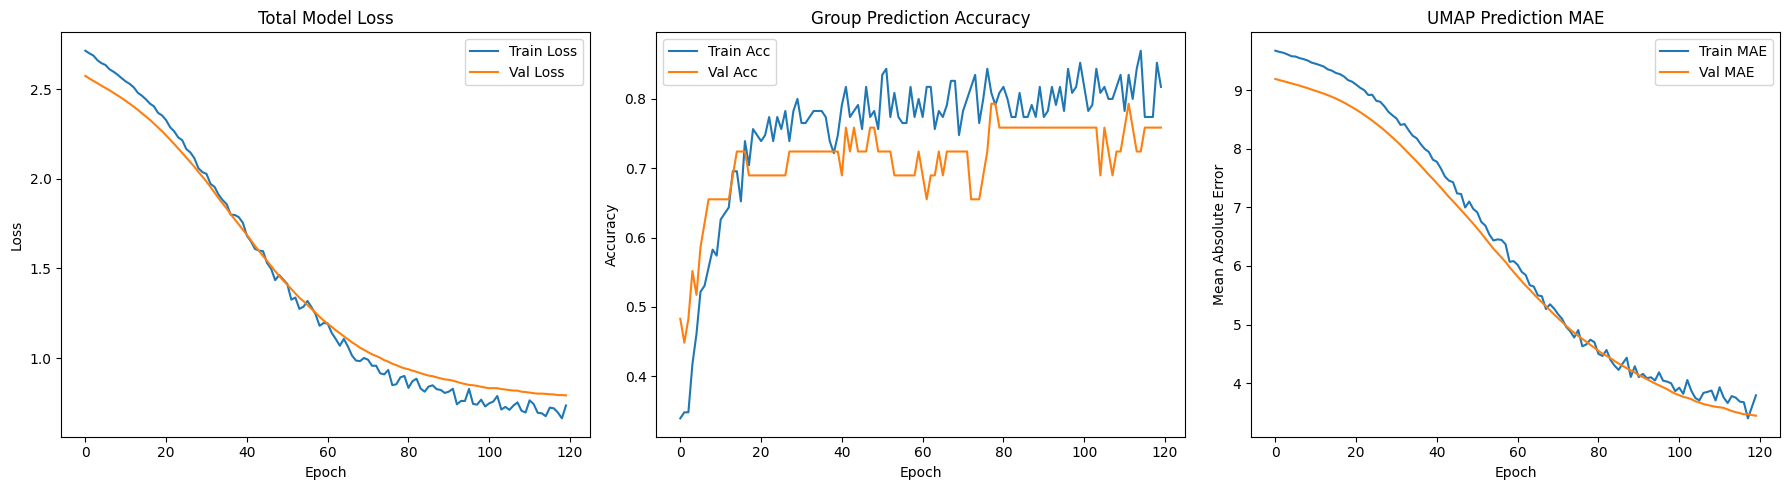

In [48]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout


inputs = Input(shape=(2, 8), name='input_layer')
lstm_out= LSTM(units=8, activation="tanh")(inputs)

dropout_ra = Dropout(0.2)(lstm_out)

umap_output = Dense(units=2, activation="linear", name="umap_prediction")(dropout_ra)
group_output = Dense(units=1, activation="sigmoid", name="group_prediction")(dropout_ra)

model = Model(inputs=inputs, outputs=[umap_output, group_output])

model.compile(
    optimizer="adam",
    loss={
        "umap_prediction": "mse",
        "group_prediction": "binary_crossentropy"
    },
    metrics={
        'umap_prediction': 'mae',                 
        'group_prediction': 'accuracy'
    },
    loss_weights={
       'umap_prediction': 0.015, 
        'group_prediction': 1.0# 8 -> 7 -> 6 
    }
)


y_train_umap = df_train_umap.groupby("Subject ID")[["UMAP1", "UMAP2"]].last()
y_train_group = df_train_umap.groupby("Subject ID")["Group"].first()

y_test_umap = df_test_umap.groupby("Subject ID")[["UMAP1", "UMAP2"]].last()
y_test_group = df_test_umap.groupby("Subject ID")["Group"].first()

y_train_dict = {
    'umap_prediction': y_train_umap,
    'group_prediction': y_train_group
}

y_test_dict = {
    'umap_prediction': y_test_umap,
    'group_prediction': y_test_group
}


y_train_dict['umap_prediction'] = np.asarray(y_train_dict['umap_prediction']).astype('float32')
y_train_dict['group_prediction'] = np.asarray(y_train_dict['group_prediction']).astype('float32')

y_test_dict['umap_prediction'] = np.asarray(y_test_dict['umap_prediction']).astype('float32')
y_test_dict['group_prediction'] = np.asarray(y_test_dict['group_prediction']).astype('float32')
history = model.fit(
    df_train_umap_3d,           
    y_train_dict,         
    epochs=120,
    batch_size=8,
    validation_data=(df_test_umap_3d, y_test_dict),
    verbose=1,

)

import matplotlib.pyplot as plt

def plot_history(history):

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))


    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Total Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(history.history['group_prediction_accuracy'], label='Train Acc')
    ax2.plot(history.history['val_group_prediction_accuracy'], label='Val Acc')
    ax2.set_title('Group Prediction Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()


    ax3.plot(history.history['umap_prediction_mae'], label='Train MAE')
    ax3.plot(history.history['val_umap_prediction_mae'], label='Val MAE')
    ax3.set_title('UMAP Prediction MAE')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Mean Absolute Error')
    ax3.legend()

    plt.tight_layout()
    plt.show()


plot_history(history)

model.save('umap_trajectory_model.keras')

# Prediciton visit 4 w UMAP + LSTM

In [49]:
def prep_data_predict_umap(df):
    scaler = joblib.load("alz_scaler_umap.save")
    df = df.copy()
    df["Group"] = df["Group"].map(map_dem)
    df["Hand"] = df["Hand"].map(map_hand)
    df["M/F"] = df["M/F"].map(map_sex)

    features_lstm = ["MR Delay", "Age", "EDUC", "SES", "MMSE", "eTIV", "nWBV", "ASF"]
    df[features_lstm] = scaler.transform(df[features_lstm])
    return df[features_lstm]

df_visit3_4_umap_clean = prep_data_predict_umap(df_visit3_4)
df_visit3_4_umap_reshaped = df_visit3_4_umap_clean.values.reshape(-1, 2, 8)

umap_model = tf.keras.models.load_model("umap_trajectory_model.keras")
umap_predictions = umap_model.predict(df_visit3_4_umap_reshaped)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


In [50]:
# Raw UMAP embedding of Visit 4 (ground truth projection for comparison)
import umap as umap_lib

df_v4 = df_visit3_4[df_visit3_4["Visit"] == 4].copy().sort_values("Subject ID").reset_index(drop=True)
df_v4["Group"] = df_v4["Group"].map(map_dem)
df_v4["Hand"] = df_v4["Hand"].map(map_hand)
df_v4["M/F"] = df_v4["M/F"].map(map_sex)

umap_features = ["Visit", "MR Delay", "M/F", "Hand", "Age", "EDUC", "SES", "MMSE", "eTIV", "nWBV", "ASF"]
reducer_v4 = umap_lib.UMAP(n_neighbors=5, min_dist=1, n_components=2, metric="euclidean", random_state=42)
raw_umap_v4 = reducer_v4.fit_transform(df_v4[umap_features])

/Users/ihsanbolum/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


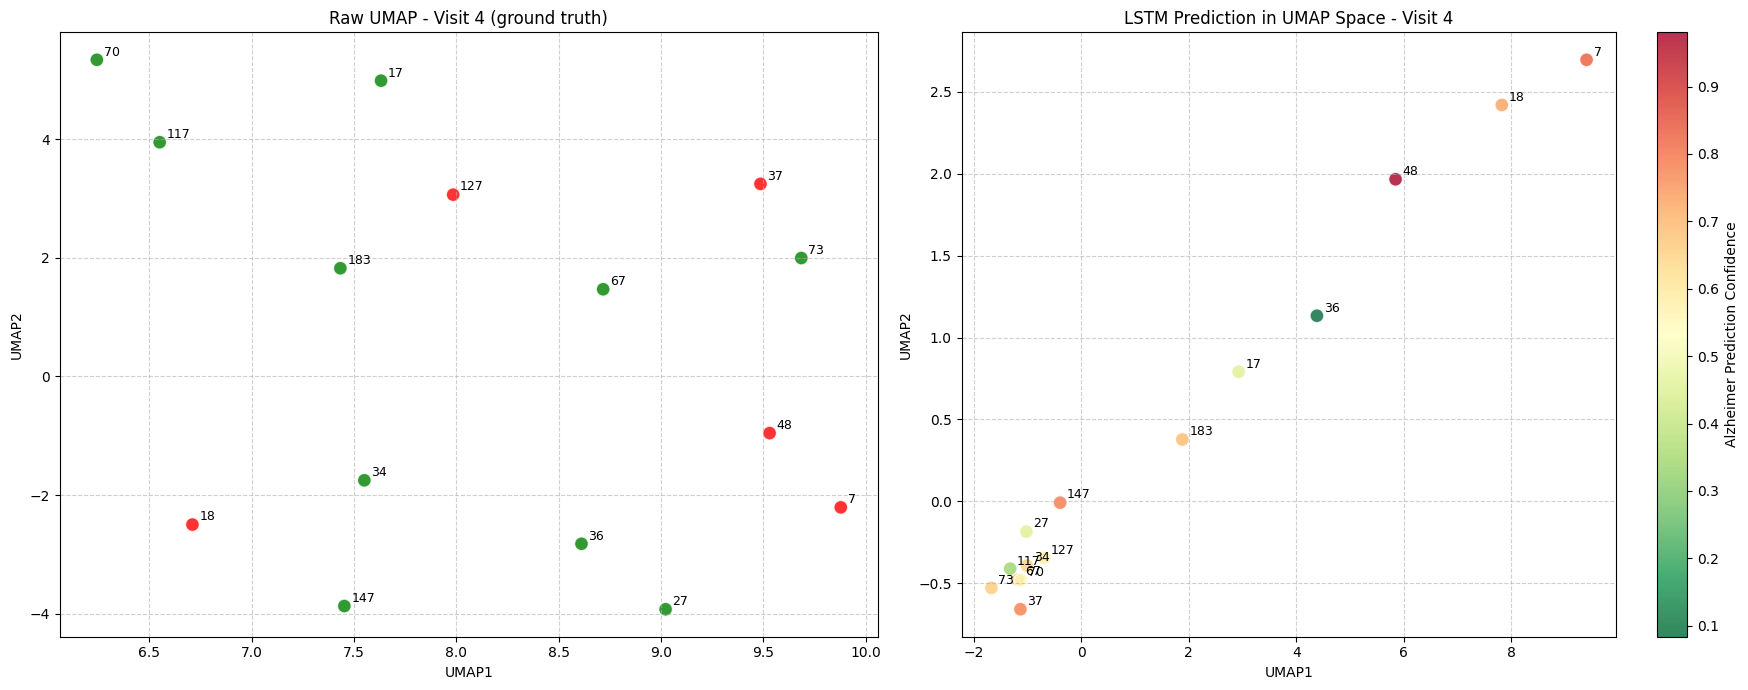

In [51]:
import matplotlib.pyplot as plt
import numpy as np

umap_coords = umap_predictions[0]
confidence = umap_predictions[1]

subject_ids = df_visit3_4.sort_values(by=["Subject ID", "Visit"])["Subject ID"].unique()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Left: raw UMAP of Visit 4
groups_v4 = df_v4["Group"].values
colors_v4 = ["red" if g == 1 else "green" for g in groups_v4]
ax1.scatter(raw_umap_v4[:, 0], raw_umap_v4[:, 1], c=colors_v4, s=100, edgecolors="w", alpha=0.8)
for i in range(len(raw_umap_v4)):
    sid = df_v4["Subject ID"].iloc[i]
    try:
        short_id = str(int(str(sid).split("_")[1]))
    except Exception:
        short_id = str(sid)
    ax1.annotate(short_id, (raw_umap_v4[i, 0], raw_umap_v4[i, 1]),
                 xytext=(5, 3), textcoords="offset points", fontsize=9)
ax1.set_title("Raw UMAP - Visit 4 (ground truth)")
ax1.set_xlabel("UMAP1"); ax1.set_ylabel("UMAP2")
ax1.grid(True, linestyle="--", alpha=0.6)

# Right: LSTM-predicted UMAP for Visit 4
sc = ax2.scatter(umap_coords[:, 0], umap_coords[:, 1],
                 c=confidence.flatten(), cmap="RdYlGn_r",
                 s=100, edgecolors="w", alpha=0.8)
cbar = plt.colorbar(sc, ax=ax2)
cbar.set_label("Alzheimer Prediction Confidence")
for i in range(len(umap_coords)):
    sid = subject_ids[i]
    try:
        short_id = str(int(str(sid).split("_")[1]))
    except Exception:
        short_id = str(sid)
    ax2.annotate(short_id, (umap_coords[i, 0], umap_coords[i, 1]),
                 xytext=(5, 3), textcoords="offset points", fontsize=9)
ax2.set_title("LSTM Prediction in UMAP Space - Visit 4")
ax2.set_xlabel("UMAP1"); ax2.set_ylabel("UMAP2")
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()